In [27]:
import pandas as pd
import pingouin as pg
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import statsmodels.api as sm

In [ ]:
#Load csv file into dataframe
df = pd.read_csv('../../../RadiomiK/Features_Global/cyl0_glob.csv')
df

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition
0,32338.0,32455.0,2.274190e+12,2.895033,67.0,2.497114,32543.0,37.152096,32395.408399,32396.0,...,5.281891,0.006676,RAD_TO_LUNG_4_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,1
1,32339.0,32452.0,2.274172e+12,2.877628,64.0,2.738984,32537.0,35.899859,32395.286571,32396.0,...,7.479260,0.003848,RAD_TO_LUNG_4_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,2
2,32336.0,32451.0,2.274120e+12,2.888346,65.5,2.623098,32539.0,36.830678,32394.909552,32395.0,...,5.642828,0.006768,RAD_TO_LUNG_4_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,3
3,32329.0,32458.0,2.273763e+12,3.011258,72.0,2.507076,32539.0,40.127979,32392.365482,32391.0,...,7.878124,0.004552,RAD_TO_LUNG_2_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,1
4,32330.0,32455.0,2.273936e+12,2.977948,69.0,2.523126,32533.0,39.099131,32393.598985,32394.0,...,5.701022,0.007985,RAD_TO_LUNG_2_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,3
5,32332.0,32457.0,2.274011e+12,2.992587,69.0,2.583730,32540.0,39.163642,32394.129211,32395.0,...,6.173102,0.007797,RAD_TO_LUNG_2_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,2
6,32326.0,32460.0,2.274073e+12,3.092705,76.0,2.553842,32553.0,42.526532,32394.570835,32394.0,...,10.138136,0.006199,RAD_TO_LUNG_4_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,3
7,32329.0,32461.0,2.274126e+12,3.078267,75.0,2.653363,32555.0,42.117601,32394.946931,32394.0,...,9.988204,0.005321,RAD_TO_LUNG_4_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,2
8,32329.0,32462.0,2.274146e+12,3.073643,77.0,2.461091,32551.0,42.435558,32395.088140,32396.0,...,7.192142,0.010203,RAD_TO_LUNG_4_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,1
9,32317.0,32470.0,2.274039e+12,3.265483,88.0,2.505607,32577.0,48.602242,32394.315644,32396.0,...,11.482843,0.009766,RAD_TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,2


In [29]:
features_names_all = df.columns[0:86]
print(features_names_all)

Index(['original_firstorder_10Percentile', 'original_firstorder_90Percentile',
       'original_firstorder_Energy', 'original_firstorder_Entropy',
       'original_firstorder_InterquartileRange',
       'original_firstorder_Kurtosis', 'original_firstorder_Maximum',
       'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean',
       'original_firstorder_Median', 'original_firstorder_Minimum',
       'original_firstorder_Range',
       'original_firstorder_RobustMeanAbsoluteDeviation',
       'original_firstorder_RootMeanSquared', 'original_firstorder_Skewness',
       'original_firstorder_TotalEnergy', 'original_firstorder_Uniformity',
       'original_firstorder_Variance', 'original_glcm_Autocorrelation',
       'original_glcm_JointAverage', 'original_glcm_ClusterProminence',
       'original_glcm_ClusterShade', 'original_glcm_ClusterTendency',
       'original_glcm_Contrast', 'original_glcm_Correlation',
       'original_glcm_DifferenceAverage', 'original_glcm_Diffe

In [30]:
#create a dataframe with the features names
df_heat_Cyl0 = pd.DataFrame(features_names_all)

df_heat_Cyl0.columns = ['Features']

# add the void columns Test-retest, positioning and volume
df_heat_Cyl0['Insert'] = 'Cyl0'
df_heat_Cyl0['Test-Retest'] = 1
df_heat_Cyl0['Positioning'] = 1
df_heat_Cyl0['Volume'] = 1

df_heat_Cyl0

,Features,Insert,Test-Retest,Positioning,Volume
0,original_firstorder_10Percentile,Cyl0,1,1,1
1,original_firstorder_90Percentile,Cyl0,1,1,1
2,original_firstorder_Energy,Cyl0,1,1,1
3,original_firstorder_Entropy,Cyl0,1,1,1
4,original_firstorder_InterquartileRange,Cyl0,1,1,1
5,original_firstorder_Kurtosis,Cyl0,1,1,1
6,original_firstorder_Maximum,Cyl0,1,1,1
7,original_firstorder_MeanAbsoluteDeviation,Cyl0,1,1,1
8,original_firstorder_Mean,Cyl0,1,1,1
9,original_firstorder_Median,Cyl0,1,1,1


In [31]:
#Load the csv file that contains the non repeatable features for Cyl0
df_nr_Cyl0 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Cyl0_all_test.csv')
df_nr_Cyl0

,Feature,Test,Manufacturer
0,original_gldm_SmallDependenceLowGrayLevelEmphasis,Test-Retest,TO-GE
1,original_glcm_Idmn,Test-Retest,TO-GE
2,original_glszm_SizeZoneNonUniformityNormalized,Test-Retest,TO-GE
3,original_gldm_LargeDependenceHighGrayLevelEmph...,Test-Retest,TO-GE
4,original_glcm_Idn,Test-Retest,TO-GE
5,original_glcm_ClusterShade,Test-Retest,TO-GE
6,original_glszm_SmallAreaEmphasis,Test-Retest,TO-GE
7,original_firstorder_Skewness,Test-Retest,TO-GE
8,original_firstorder_Kurtosis,Test-Retest,TO-GE
9,original_glcm_Imc2,Test-Retest,TO-GE


In [32]:
# Itera su tutte le righe in df_heat
for index, row in df_heat_Cyl0.iterrows():
    # Se il nome della feature è presente in df_nr_Cyl0 con Test = "Volume"
    if row['Features'] in df_nr_Cyl0[df_nr_Cyl0['Test'] == 'Volume']['Feature'].values:
        # Imposta il valore nella colonna "Volume" a 0
        df_heat_Cyl0.loc[index, 'Volume'] = 0
    if row['Features'] in df_nr_Cyl0[df_nr_Cyl0['Test'] == 'Positioning']['Feature'].values:
        df_heat_Cyl0.loc[index, 'Positioning'] = 0
    if row['Features'] in df_nr_Cyl0[df_nr_Cyl0['Test'] == 'Test-Retest']['Feature'].values:
        df_heat_Cyl0.loc[index, 'Test-Retest'] = 0    

    
#show all rows
pd.set_option('display.max_rows', None)
df_heat_Cyl0


,Features,Insert,Test-Retest,Positioning,Volume
0,original_firstorder_10Percentile,Cyl0,1,1,1
1,original_firstorder_90Percentile,Cyl0,1,1,1
2,original_firstorder_Energy,Cyl0,1,1,0
3,original_firstorder_Entropy,Cyl0,1,1,1
4,original_firstorder_InterquartileRange,Cyl0,1,1,1
5,original_firstorder_Kurtosis,Cyl0,0,1,1
6,original_firstorder_Maximum,Cyl0,1,1,1
7,original_firstorder_MeanAbsoluteDeviation,Cyl0,1,1,1
8,original_firstorder_Mean,Cyl0,1,1,1
9,original_firstorder_Median,Cyl0,1,1,1


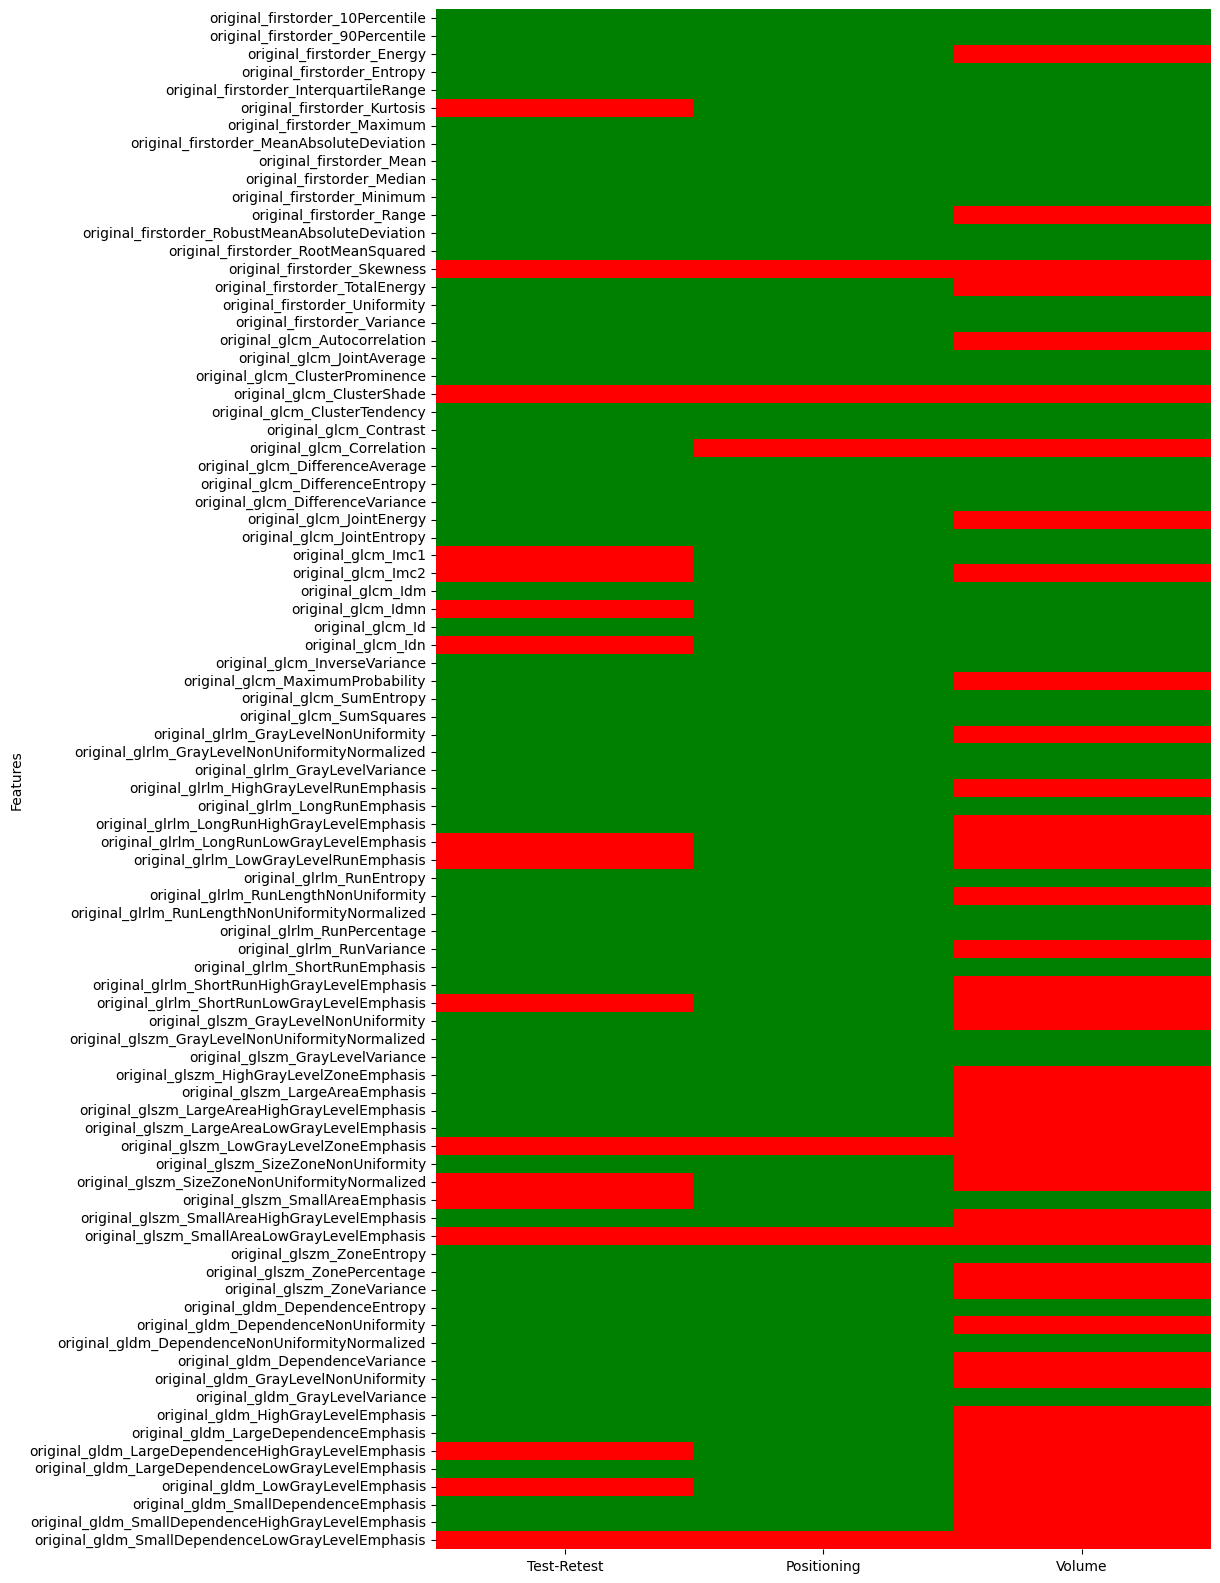

,Insert,Test-Retest,Positioning,Volume
Features,,,,
original_firstorder_10Percentile,Cyl0,1,1,1
original_firstorder_90Percentile,Cyl0,1,1,1
original_firstorder_Energy,Cyl0,1,1,0
original_firstorder_Entropy,Cyl0,1,1,1
original_firstorder_InterquartileRange,Cyl0,1,1,1
original_firstorder_Kurtosis,Cyl0,0,1,1
original_firstorder_Maximum,Cyl0,1,1,1
original_firstorder_MeanAbsoluteDeviation,Cyl0,1,1,1
original_firstorder_Mean,Cyl0,1,1,1


In [33]:
# Imposta 'Features' come indice del DataFrame
df_heat_Cyl0 = df_heat_Cyl0.set_index('Features')

# Seleziona solo le colonne che vuoi includere nella heatmap
heatmap_data = df_heat_Cyl0[['Test-Retest', 'Positioning', 'Volume']]

# Crea una mappa di colori con il rosso per 0 e il verde per 1
cmap = sns.color_palette(["red", "green"])

# Imposta le dimensioni della figura
plt.figure(figsize=(10, 20))

# Crea la heatmap
sns.heatmap(heatmap_data, cmap=cmap, cbar=False, yticklabels=True)

# Mostra il grafico
plt.show()

df_heat_Cyl0 

                                                    Cyl0_TR  Cyl0_Pos  \
Features                                                                
original_firstorder_10Percentile                          1         1   
original_firstorder_90Percentile                          1         1   
original_firstorder_Energy                                1         1   
original_firstorder_Entropy                               1         1   
original_firstorder_InterquartileRange                    1         1   
original_firstorder_Kurtosis                              0         1   
original_firstorder_Maximum                               1         1   
original_firstorder_MeanAbsoluteDeviation                 1         1   
original_firstorder_Mean                                  1         1   
original_firstorder_Median                                1         1   
original_firstorder_Minimum                               1         1   
original_firstorder_Range                          

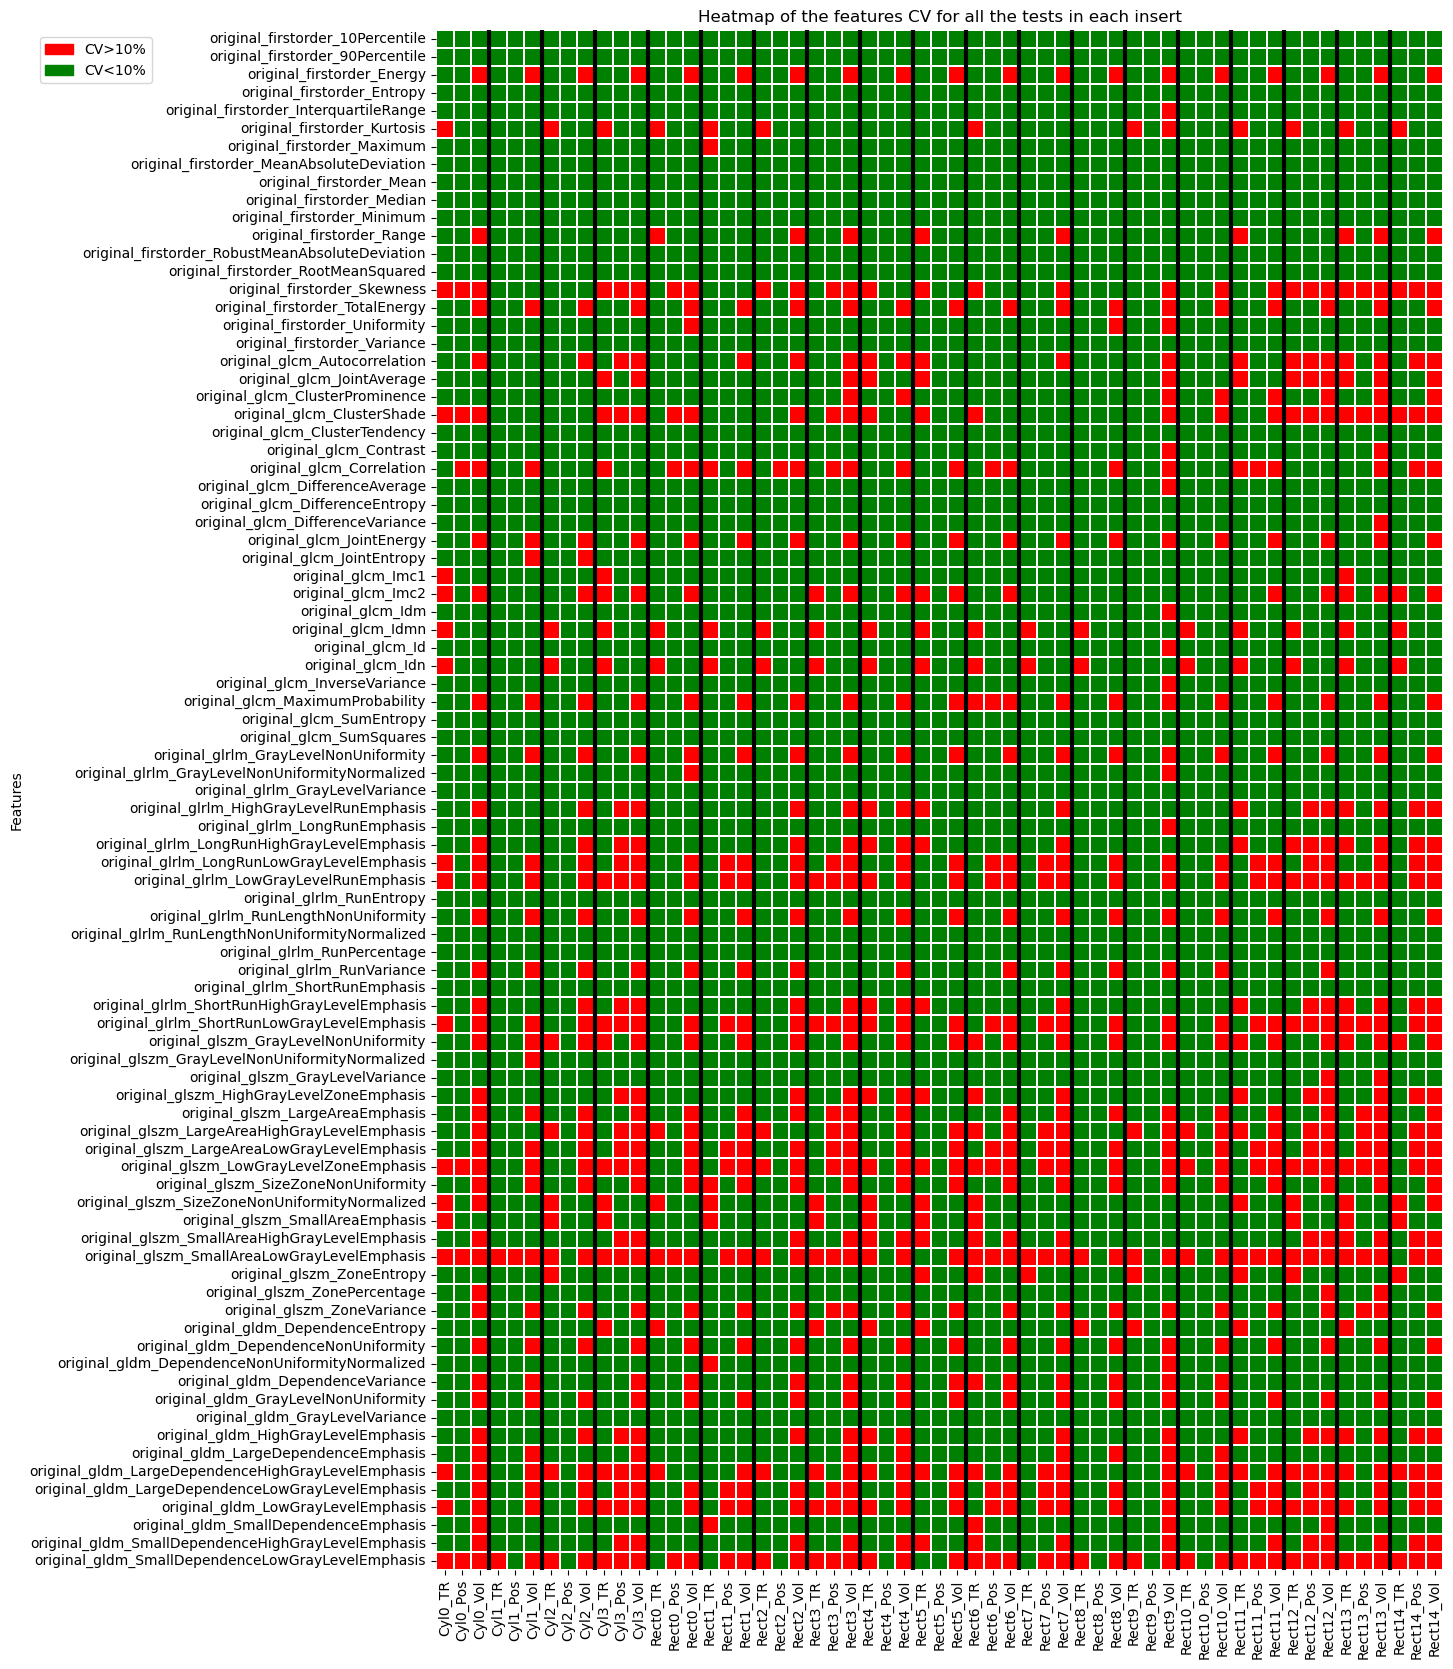

,Features,Cyl0_TR,Cyl1_TR,Cyl2_TR,Cyl3_TR,Rect0_TR,Rect1_TR,Rect2_TR,Rect3_TR,Rect4_TR,...,Rect5_Vol,Rect6_Vol,Rect7_Vol,Rect8_Vol,Rect9_Vol,Rect10_Vol,Rect11_Vol,Rect12_Vol,Rect13_Vol,Rect14_Vol
0,original_firstorder_10Percentile,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1,original_firstorder_90Percentile,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2,original_firstorder_Energy,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,original_firstorder_Entropy,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
4,original_firstorder_InterquartileRange,1,1,1,1,1,1,1,1,1,...,1,1,1,1,0,1,1,1,1,1
5,original_firstorder_Kurtosis,0,1,0,0,0,0,0,1,1,...,1,1,1,1,0,1,1,1,1,1
6,original_firstorder_Maximum,1,1,1,1,1,0,1,1,1,...,1,1,1,1,1,1,1,1,1,1
7,original_firstorder_MeanAbsoluteDeviation,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
8,original_firstorder_Mean,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
9,original_firstorder_Median,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [38]:

import matplotlib.patches as mpatches
#Repeat everything for Cyl1
#Load csv file into dataframe
df = pd.read_csv('../../../../RadiomiK/Features_Global/cyl1_glob.csv')

features_names_all = df.columns[0:86]

#create a dataframe with the features names
df_heat = pd.DataFrame(features_names_all)

df_heat.columns = ['Features']

# add the void columns Test-retest, Cyl1_Pos and Cyl1_Vol
df_heat['Cyl0_TR'] = 1
df_heat['Cyl1_TR'] = 1
df_heat['Cyl2_TR'] = 1
df_heat['Cyl3_TR'] = 1
df_heat['Rect0_TR'] = 1
df_heat['Rect1_TR'] = 1
df_heat['Rect2_TR'] = 1
df_heat['Rect3_TR'] = 1
df_heat['Rect4_TR'] = 1
df_heat['Rect5_TR'] = 1
df_heat['Rect6_TR'] = 1
df_heat['Rect7_TR'] = 1
df_heat['Rect8_TR'] = 1
df_heat['Rect9_TR'] = 1
df_heat['Rect10_TR'] = 1
df_heat['Rect11_TR'] = 1
df_heat['Rect12_TR'] = 1
df_heat['Rect13_TR'] = 1
df_heat['Rect14_TR'] = 1

df_heat['Cyl0_Pos'] = 1
df_heat['Cyl1_Pos'] = 1
df_heat['Cyl2_Pos'] = 1
df_heat['Cyl3_Pos'] = 1
df_heat['Rect0_Pos'] = 1
df_heat['Rect1_Pos'] = 1
df_heat['Rect2_Pos'] = 1
df_heat['Rect3_Pos'] = 1
df_heat['Rect4_Pos'] = 1
df_heat['Rect5_Pos'] = 1
df_heat['Rect6_Pos'] = 1
df_heat['Rect7_Pos'] = 1
df_heat['Rect8_Pos'] = 1
df_heat['Rect9_Pos'] = 1
df_heat['Rect10_Pos'] = 1
df_heat['Rect11_Pos'] = 1
df_heat['Rect12_Pos'] = 1
df_heat['Rect13_Pos'] = 1
df_heat['Rect14_Pos'] = 1

df_heat['Cyl0_Vol'] = 1
df_heat['Cyl1_Vol'] = 1
df_heat['Cyl2_Vol'] = 1
df_heat['Cyl3_Vol'] = 1
df_heat['Rect0_Vol'] = 1
df_heat['Rect1_Vol'] = 1
df_heat['Rect2_Vol'] = 1
df_heat['Rect3_Vol'] = 1
df_heat['Rect4_Vol'] = 1
df_heat['Rect5_Vol'] = 1
df_heat['Rect6_Vol'] = 1
df_heat['Rect7_Vol'] = 1
df_heat['Rect8_Vol'] = 1
df_heat['Rect9_Vol'] = 1
df_heat['Rect10_Vol'] = 1
df_heat['Rect11_Vol'] = 1
df_heat['Rect12_Vol'] = 1
df_heat['Rect13_Vol'] = 1
df_heat['Rect14_Vol'] = 1


#Load the csv file that contains the non repeatable features for Cyl1
df_nr_Cyl0 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Cyl0_all_test.csv')
df_nr_Cyl1 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Cyl1_all_test.csv')
df_nr_Cyl2 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Cyl2_all_test.csv')
df_nr_Cyl3 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Cyl3_all_test.csv')
df_nr_Rect0 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect0_all_test.csv')
df_nr_Rect1 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect1_all_test.csv')
df_nr_Rect2 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect2_all_test.csv')
df_nr_Rect3 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect3_all_test.csv')
df_nr_Rect4 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect4_all_test.csv')
df_nr_Rect5 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect5_all_test.csv')
df_nr_Rect6 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect6_all_test.csv')
df_nr_Rect7 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect7_all_test.csv')
df_nr_Rect8 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect8_all_test.csv')
df_nr_Rect9 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect9_all_test.csv')
df_nr_Rect10 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect10_all_test.csv')
df_nr_Rect11 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect11_all_test.csv')
df_nr_Rect12 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect12_all_test.csv')
df_nr_Rect13 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect13_all_test.csv')
df_nr_Rect14 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Rect14_all_test.csv')


# Itera su tutte le righe in df_heat
for index, row in df_heat.iterrows():
    if row['Features'] in df_nr_Cyl0[df_nr_Cyl0['Test'] == 'Volume']['Feature'].values:
        # Imposta il valore nella colonna "Cyl0_Vol" a 0
        df_heat.loc[index, 'Cyl0_Vol'] = 0
    if row['Features'] in df_nr_Cyl0[df_nr_Cyl0['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Cyl0_Pos'] = 0
    if row['Features'] in df_nr_Cyl0[df_nr_Cyl0['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Cyl0_TR'] = 0
    if row['Features'] in df_nr_Cyl1[df_nr_Cyl1['Test'] == 'Volume']['Feature'].values:
        # Imposta il valore nella colonna "Cyl1_Vol" a 0
        df_heat.loc[index, 'Cyl1_Vol'] = 0
    if row['Features'] in df_nr_Cyl1[df_nr_Cyl1['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Cyl1_Pos'] = 0
    if row['Features'] in df_nr_Cyl1[df_nr_Cyl1['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Cyl1_TR'] = 0
    if row['Features'] in df_nr_Cyl2[df_nr_Cyl2['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Cyl2_Vol'] = 0
    if row['Features'] in df_nr_Cyl2[df_nr_Cyl2['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Cyl2_Pos'] = 0
    if row['Features'] in df_nr_Cyl2[df_nr_Cyl2['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Cyl2_TR'] = 0
    if row['Features'] in df_nr_Cyl3[df_nr_Cyl3['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Cyl3_Vol'] = 0
    if row['Features'] in df_nr_Cyl3[df_nr_Cyl3['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Cyl3_Pos'] = 0
    if row['Features'] in df_nr_Cyl3[df_nr_Cyl3['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Cyl3_TR'] = 0
    if row['Features'] in df_nr_Rect0[df_nr_Rect0['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect0_Vol'] = 0
    if row['Features'] in df_nr_Rect0[df_nr_Rect0['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect0_Pos'] = 0
    if row['Features'] in df_nr_Rect0[df_nr_Rect0['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect0_TR'] = 0
    if row['Features'] in df_nr_Rect1[df_nr_Rect1['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect1_Vol'] = 0
    if row['Features'] in df_nr_Rect1[df_nr_Rect1['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect1_Pos'] = 0
    if row['Features'] in df_nr_Rect1[df_nr_Rect1['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect1_TR'] = 0
    if row['Features'] in df_nr_Rect2[df_nr_Rect2['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect2_Vol'] = 0
    if row['Features'] in df_nr_Rect2[df_nr_Rect2['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect2_Pos'] = 0
    if row['Features'] in df_nr_Rect2[df_nr_Rect2['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect2_TR'] = 0
    if row['Features'] in df_nr_Rect3[df_nr_Rect3['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect3_Vol'] = 0
    if row['Features'] in df_nr_Rect3[df_nr_Rect3['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect3_Pos'] = 0
    if row['Features'] in df_nr_Rect3[df_nr_Rect3['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect3_TR'] = 0
    if row['Features'] in df_nr_Rect4[df_nr_Rect4['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect4_Vol'] = 0
    if row['Features'] in df_nr_Rect4[df_nr_Rect4['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect4_Pos'] = 0
    if row['Features'] in df_nr_Rect4[df_nr_Rect4['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect4_TR'] = 0
    if row['Features'] in df_nr_Rect5[df_nr_Rect5['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect5_Vol'] = 0
    if row['Features'] in df_nr_Rect5[df_nr_Rect5['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect5_Pos'] = 0
    if row['Features'] in df_nr_Rect5[df_nr_Rect5['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect5_TR'] = 0
    if row['Features'] in df_nr_Rect6[df_nr_Rect6['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect6_Vol'] = 0
    if row['Features'] in df_nr_Rect6[df_nr_Rect6['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect6_Pos'] = 0
    if row['Features'] in df_nr_Rect6[df_nr_Rect6['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect6_TR'] = 0
    if row['Features'] in df_nr_Rect7[df_nr_Rect7['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect7_Vol'] = 0
    if row['Features'] in df_nr_Rect7[df_nr_Rect7['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect7_Pos'] = 0
    if row['Features'] in df_nr_Rect7[df_nr_Rect7['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect7_TR'] = 0
    if row['Features'] in df_nr_Rect8[df_nr_Rect8['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect8_Vol'] = 0
    if row['Features'] in df_nr_Rect8[df_nr_Rect8['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect8_Pos'] = 0
    if row['Features'] in df_nr_Rect8[df_nr_Rect8['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect8_TR'] = 0
    if row['Features'] in df_nr_Rect9[df_nr_Rect9['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect9_Vol'] = 0
    if row['Features'] in df_nr_Rect9[df_nr_Rect9['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect9_Pos'] = 0
    if row['Features'] in df_nr_Rect9[df_nr_Rect9['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect9_TR'] = 0
    if row['Features'] in df_nr_Rect10[df_nr_Rect10['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect10_Vol'] = 0
    if row['Features'] in df_nr_Rect10[df_nr_Rect10['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect10_Pos'] = 0
    if row['Features'] in df_nr_Rect10[df_nr_Rect10['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect10_TR'] = 0
    if row['Features'] in df_nr_Rect11[df_nr_Rect11['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect11_Vol'] = 0
    if row['Features'] in df_nr_Rect11[df_nr_Rect11['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect11_Pos'] = 0
    if row['Features'] in df_nr_Rect11[df_nr_Rect11['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect11_TR'] = 0
    if row['Features'] in df_nr_Rect12[df_nr_Rect12['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect12_Vol'] = 0
    if row['Features'] in df_nr_Rect12[df_nr_Rect12['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect12_Pos'] = 0
    if row['Features'] in df_nr_Rect12[df_nr_Rect12['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect12_TR'] = 0
    if row['Features'] in df_nr_Rect13[df_nr_Rect13['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect13_Vol'] = 0
    if row['Features'] in df_nr_Rect13[df_nr_Rect13['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect13_Pos'] = 0
    if row['Features'] in df_nr_Rect13[df_nr_Rect13['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect13_TR'] = 0
    if row['Features'] in df_nr_Rect14[df_nr_Rect14['Test'] == 'Volume']['Feature'].values:
        df_heat.loc[index, 'Rect14_Vol'] = 0
    if row['Features'] in df_nr_Rect14[df_nr_Rect14['Test'] == 'Positioning']['Feature'].values:
        df_heat.loc[index, 'Rect14_Pos'] = 0
    if row['Features'] in df_nr_Rect14[df_nr_Rect14['Test'] == 'Test-Retest']['Feature'].values:
        df_heat.loc[index, 'Rect14_TR'] = 0

# Imposta 'Features' come indice del DataFrame
df_heat_index = df_heat.set_index('Features')

#Elimina dal dataframe le righe che hanno in Features la stringa 'ngtdm'
df_heat_index = df_heat_index[~df_heat_index.index.str.contains('ngtdm')]

# Seleziona solo le colonne che vuoi includere nella heatmap
heatmap_data = df_heat_index
# Cambia l'ordine delle colonne Cyl0_TR, Cyl0_Pos, Cyl0_Vol, Cyl1_TR, Cyl1_Pos, Cyl1_Vol, Cyl2_TR, Cyl2_Pos, Cyl2_Vol, Cyl3_TR, Cyl3_Pos, Cyl3_Vol, Rect0_TR, Rect0_Pos, Rect0_Vol, Rect1_TR, Rect1_Pos, Rect1_Vol, Rect2_TR, Rect2_Pos, Rect2_Vol, Rect3_TR, Rect3_Pos, Rect3_Vol, Rect4_TR, Rect4_Pos, Rect4_Vol, Rect5_TR, Rect5_Pos, Rect5_Vol, Rect6_TR, Rect6_Pos, Rect6_Vol, Rect7_TR, Rect7_Pos, Rect7_Vol, Rect8_TR, Rect8_Pos, Rect8_Vol, Rect9_TR, Rect9_Pos, Rect9_Vol, Rect10_TR, Rect10_Pos, Rect10_Vol, Rect11_TR, Rect11_Pos, Rect11_Vol, Rect12_TR, Rect12_Pos, Rect12_Vol, Rect13_TR, Rect13_Pos, Rect13_Vol, Rect14_TR, Rect14_Pos, Rect14_Vol
heatmap_data = heatmap_data[['Cyl0_TR', 'Cyl0_Pos', 'Cyl0_Vol', 'Cyl1_TR', 'Cyl1_Pos', 'Cyl1_Vol', 'Cyl2_TR', 'Cyl2_Pos', 'Cyl2_Vol', 'Cyl3_TR', 'Cyl3_Pos', 'Cyl3_Vol', 'Rect0_TR', 'Rect0_Pos', 'Rect0_Vol', 'Rect1_TR', 'Rect1_Pos', 'Rect1_Vol', 'Rect2_TR', 'Rect2_Pos', 'Rect2_Vol', 'Rect3_TR', 'Rect3_Pos', 'Rect3_Vol', 'Rect4_TR', 'Rect4_Pos', 'Rect4_Vol', 'Rect5_TR', 'Rect5_Pos', 'Rect5_Vol', 'Rect6_TR', 'Rect6_Pos', 'Rect6_Vol', 'Rect7_TR', 'Rect7_Pos', 'Rect7_Vol', 'Rect8_TR', 'Rect8_Pos', 'Rect8_Vol', 'Rect9_TR', 'Rect9_Pos', 'Rect9_Vol', 'Rect10_TR', 'Rect10_Pos', 'Rect10_Vol', 'Rect11_TR', 'Rect11_Pos', 'Rect11_Vol', 'Rect12_TR', 'Rect12_Pos', 'Rect12_Vol', 'Rect13_TR', 'Rect13_Pos', 'Rect13_Vol', 'Rect14_TR', 'Rect14_Pos', 'Rect14_Vol']]   
print(heatmap_data)
# Crea una mappa di colori con il rosso per 0 e il verde per 1
cmap = sns.color_palette(["red", "green"])

# Imposta le dimensioni della figura
plt.figure(figsize=(13, 20))

# Crea la heatmap
sns.heatmap(heatmap_data, cmap=cmap, cbar=False, yticklabels=True, linewidths=0.01)
#Ogni 3 colonne inserisci una riga verticale nera 
for i in range(3, len(heatmap_data.columns), 3):
    plt.axvline(i, color='black', lw=3)
# Crea una legenda personalizzata
red_patch = mpatches.Patch(color='red', label='CV>10%')
green_patch = mpatches.Patch(color='green', label='CV<10%')
plt.legend(handles=[red_patch, green_patch], bbox_to_anchor=(-0.4, 1), loc='upper left')

# Imposta le etichette dell'asse x per essere scritte verticalmente
plt.xticks(rotation=90)

#set the title
plt.title('Heatmap of the features CV for all the tests in each insert')


# Mostra il grafico
plt.show()

df_heat

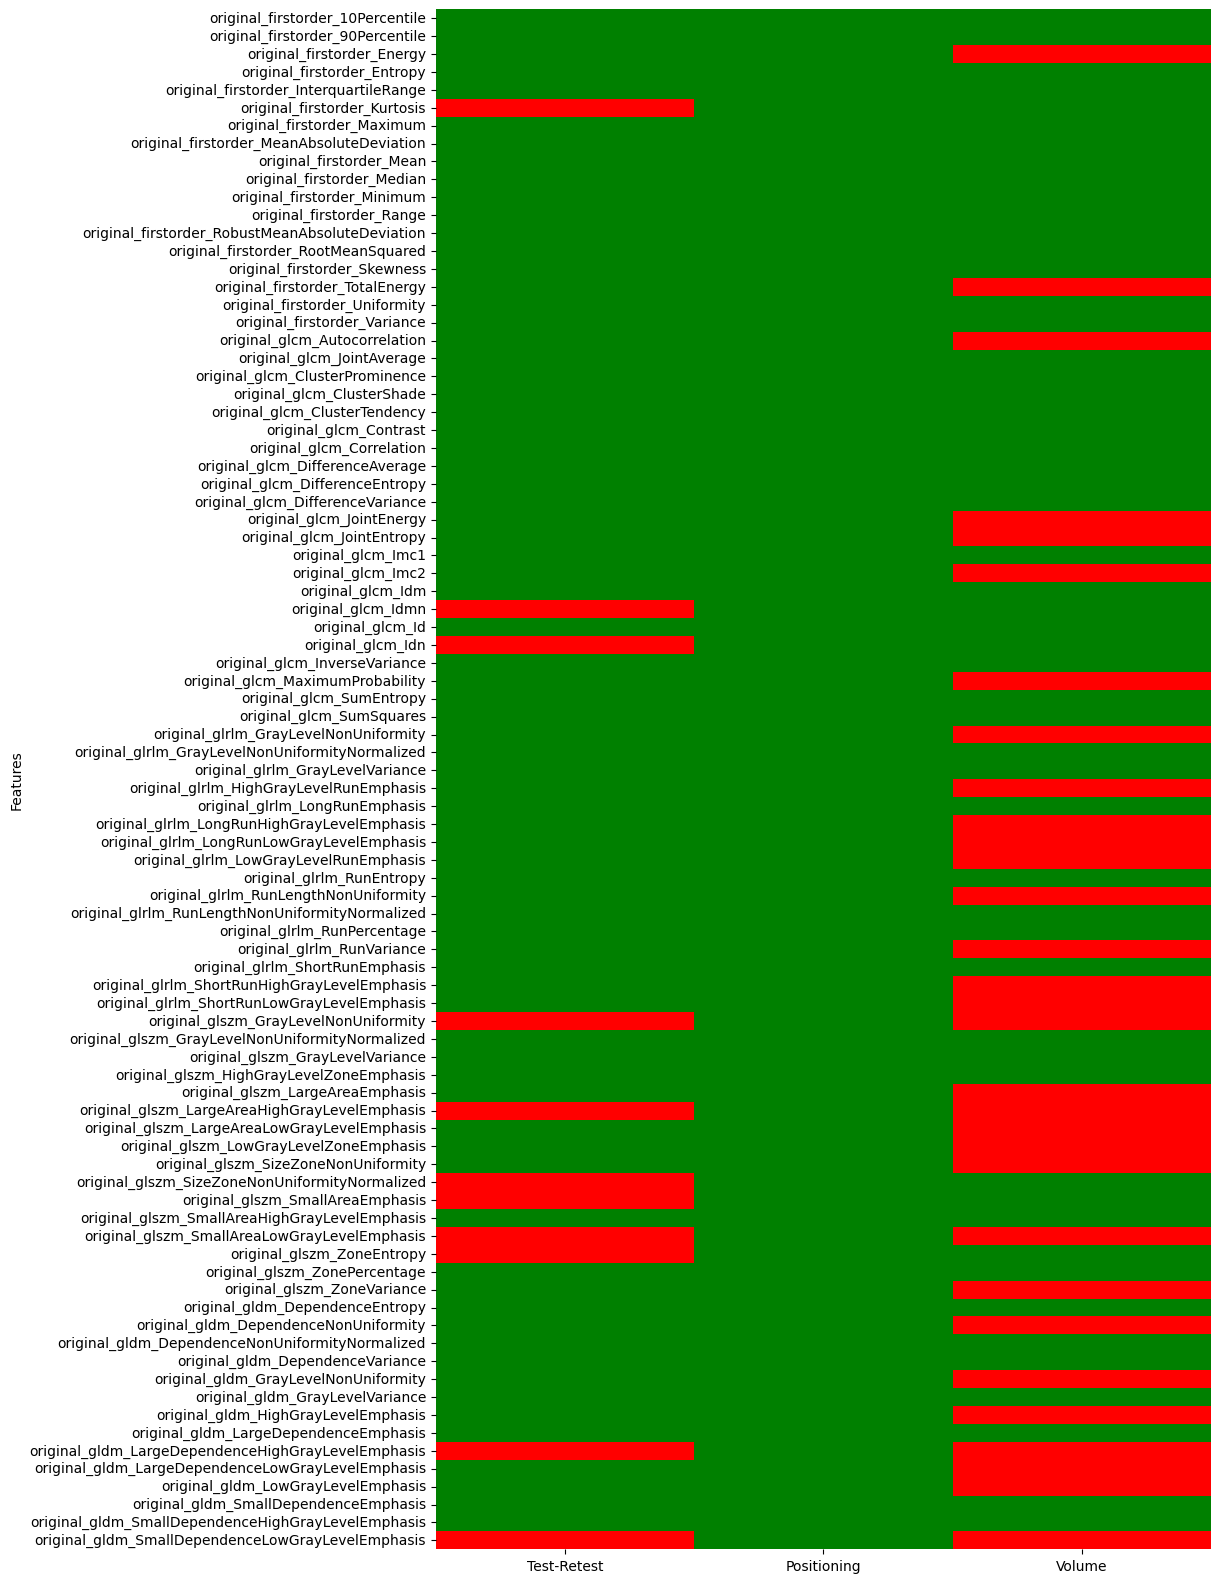

In [35]:
#Repeat everything for Cyl2
#Load csv file into dataframe
df = pd.read_csv('../../../../RadiomiK/Features_Global/cyl2_glob.csv')

features_names_all = df.columns[0:86]

#create a dataframe with the features names
df_heat_Cyl2 = pd.DataFrame(features_names_all)

df_heat_Cyl2.columns = ['Features']

# add the void columns Test-retest, positioning and volume
df_heat_Cyl2['Insert'] = 'Cyl2'
df_heat_Cyl2['Test-Retest'] = 1
df_heat_Cyl2['Positioning'] = 1
df_heat_Cyl2['Volume'] = 1

#Load the csv file that contains the non repeatable features for Cyl2
df_nr_Cyl2 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Cyl2_all_test.csv')

# Itera su tutte le righe in df_heat
for index, row in df_heat_Cyl2.iterrows():
    # Se il nome della feature è presente in df_nr_Cyl2 con Test = "Volume"
    if row['Features'] in df_nr_Cyl2[df_nr_Cyl2['Test'] == 'Volume']['Feature'].values:
        # Imposta il valore nella colonna "Volume" a 0
        df_heat_Cyl2.loc[index, 'Volume'] = 0
    if row['Features'] in df_nr_Cyl2[df_nr_Cyl2['Test'] == 'Positioning']['Feature'].values:
        df_heat_Cyl2.loc[index, 'Positioning'] = 0
    if row['Features'] in df_nr_Cyl2[df_nr_Cyl2['Test'] == 'Test-Retest']['Feature'].values:
        df_heat_Cyl2.loc[index, 'Test-Retest'] = 0

# Imposta 'Features' come indice del DataFrame
df_heat_Cyl2 = df_heat_Cyl2.set_index('Features')

# Seleziona solo le colonne che vuoi includere nella heatmap
heatmap_data = df_heat_Cyl2[['Test-Retest', 'Positioning', 'Volume']]

# Crea una mappa di colori con il rosso per 0 e il verde per 1
cmap = sns.color_palette(["red", "green"])

# Imposta le dimensioni della figura
plt.figure(figsize=(10, 20))

# Crea la heatmap
sns.heatmap(heatmap_data, cmap=cmap, cbar=False, yticklabels=True)

# Mostra il grafico
plt.show()

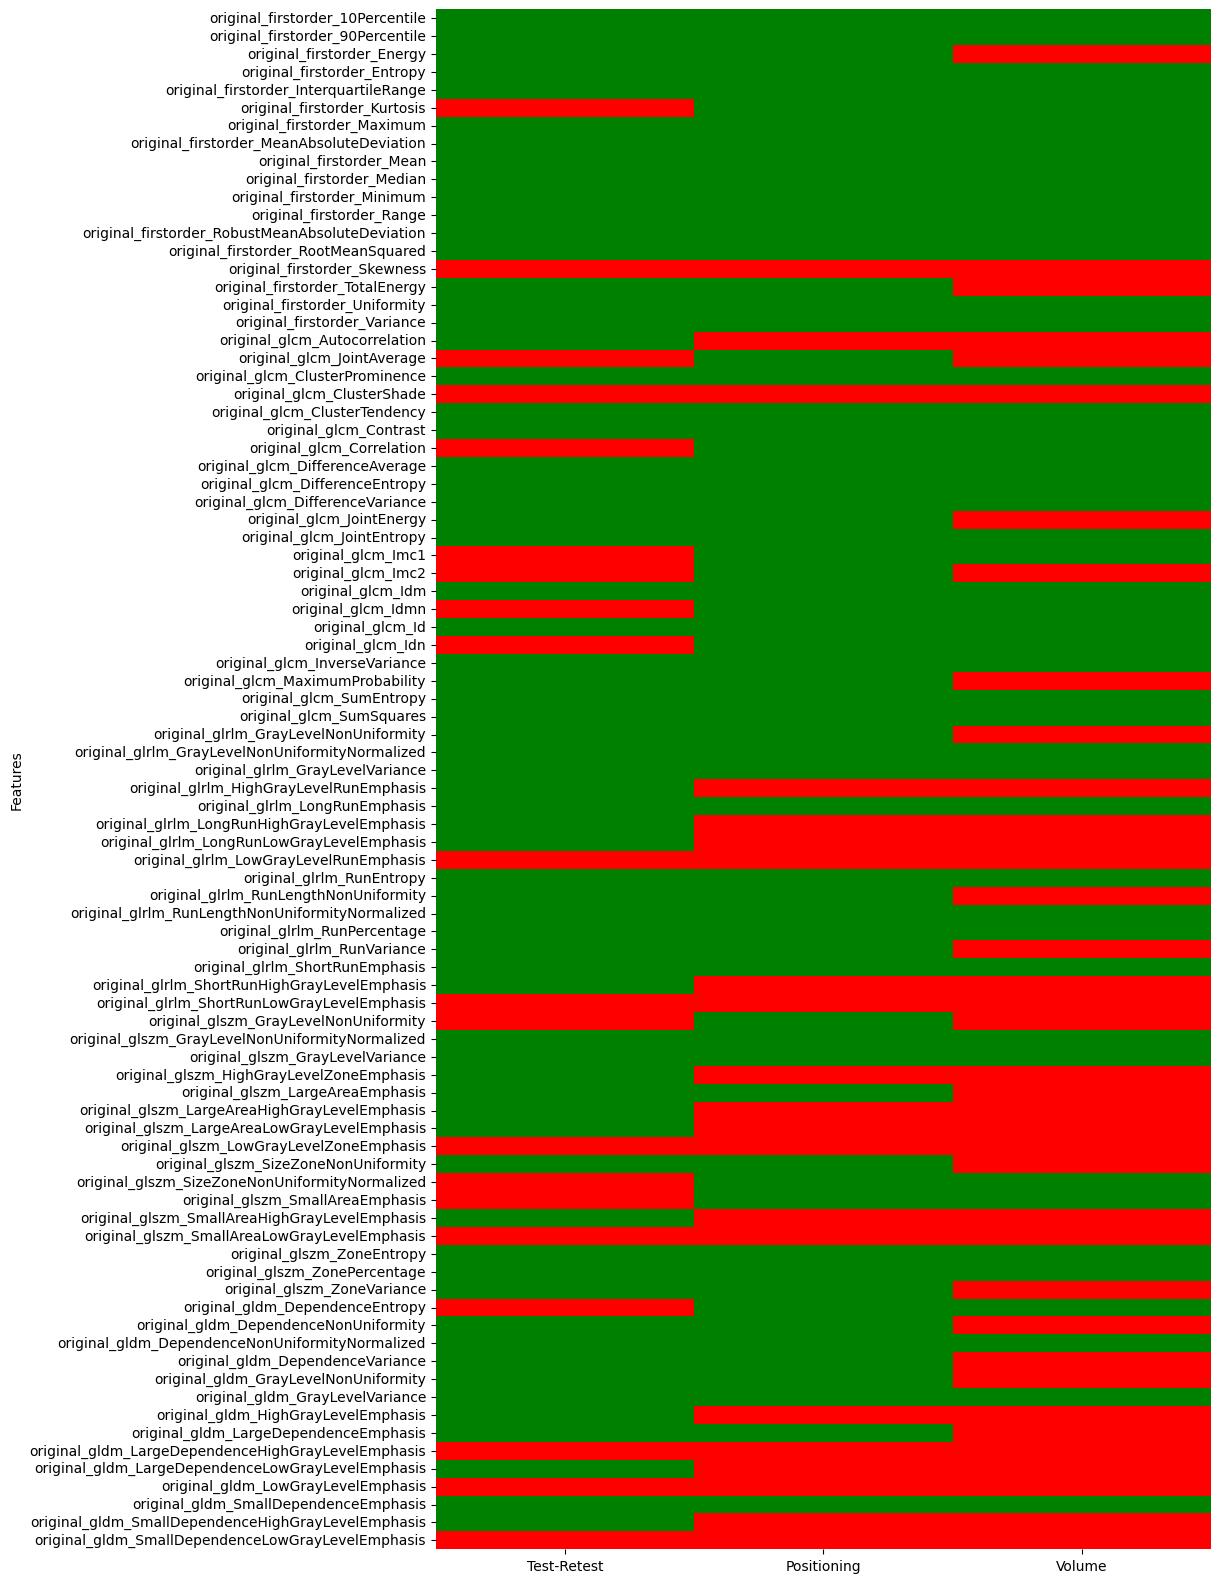

In [36]:
# Repeat everything for Cyl3
#Load csv file into dataframe
df = pd.read_csv('../../../../RadiomiK/Features_Global/cyl3_glob.csv')

features_names_all = df.columns[0:86]

#create a dataframe with the features names
df_heat_Cyl3 = pd.DataFrame(features_names_all)

df_heat_Cyl3.columns = ['Features']

# add the void columns Test-retest, positioning and volume
df_heat_Cyl3['Insert'] = 'Cyl3'
df_heat_Cyl3['Test-Retest'] = 1
df_heat_Cyl3['Positioning'] = 1
df_heat_Cyl3['Volume'] = 1

#Load the csv file that contains the non repeatable features for Cyl3
df_nr_Cyl3 = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Cyl3_all_test.csv')

# Itera su tutte le righe in df_heat
for index, row in df_heat_Cyl3.iterrows():
    # Se il nome della feature è presente in df_nr_Cyl3 con Test = "Volume"
    if row['Features'] in df_nr_Cyl3[df_nr_Cyl3['Test'] == 'Volume']['Feature'].values:
        # Imposta il valore nella colonna "Volume" a 0
        df_heat_Cyl3.loc[index, 'Volume'] = 0
    if row['Features'] in df_nr_Cyl3[df_nr_Cyl3['Test'] == 'Positioning']['Feature'].values:
        df_heat_Cyl3.loc[index, 'Positioning'] = 0
    if row['Features'] in df_nr_Cyl3[df_nr_Cyl3['Test'] == 'Test-Retest']['Feature'].values:
        df_heat_Cyl3.loc[index, 'Test-Retest'] = 0

# Imposta 'Features' come indice del DataFrame
df_heat_Cyl3 = df_heat_Cyl3.set_index('Features')

# Seleziona solo le colonne che vuoi includere nella heatmap
heatmap_data = df_heat_Cyl3[['Test-Retest', 'Positioning', 'Volume']]
# Crea una mappa di colori con il rosso per 0 e il verde per 1
cmap = sns.color_palette(["red", "green"])

# Imposta le dimensioni della figura
plt.figure(figsize=(10, 20))

# Crea la heatmap
sns.heatmap(heatmap_data, cmap=cmap, cbar=False, yticklabels=True)

# Mostra il grafico
plt.show()

In [37]:
#unisci i dataframe
df_heat = pd.concat([df_heat_Cyl0, df_heat_Cyl1, df_heat_Cyl2, df_heat_Cyl3], axis=0)
df_heat

NameError: name 'df_heat_Cyl1' is not defined

In [ ]:
#Disegna la heatmap con tutti i dati mettendo nelle x i test riferiti all'inserto che si sta considerando
# Imposta 'Features' come indice del DataFrame
df_heat = df_heat.set_index('Features')

# Seleziona solo le colonne che vuoi includere nella heatmap
heatmap_data = df_heat[['Test-Retest', 'Positioning', 'Volume']]

# Crea una mappa di colori con il rosso per 0 e il verde per 1
cmap = sns.color_palette(["red", "green"])

# Imposta le dimensioni della figura
plt.figure(figsize=(10, 20))

# Crea la heatmap
sns.heatmap(heatmap_data, cmap=cmap, cbar=False, yticklabels=True)

# Mostra il grafico
plt.show()


KeyError: "None of ['Features'] are in the columns"